- Business Problem
- Understanding the Dataset
- Data Collection
- Data Cleaning
- EDA
- Feature Engineering
- Feature Selection
- Data Preprocessing
- Train/Test Split
- Model Building
- Model Evaluate
- Error Analysis
- Model Interpretation and Tuning
- Saving the Model
- Make Predictions on Unseen Data

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

RANDOM_STATE = 42
pd.set_option('display.max_columns',None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Environment is ready')

Environment is ready


In [3]:
df = sns.load_dataset('diamonds')
print('Shape:', df.shape)

Shape: (53940, 10)


In [4]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


In [7]:
df.describe(include='category').T

,count,unique,top,freq
cut,53940,5,Ideal,21551
color,53940,7,G,11292
clarity,53940,8,SI1,13065


In [8]:
min(df['x'])

0.0

In [9]:
print('Duplicate Rows :', df.duplicated().sum())

Duplicate Rows : 146


In [10]:
print('Missing values per column:\n', df.isnull().sum())

Missing values per column:
 carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [11]:
zero_dims = df[(df['x']== 0) | (df['y'] == 0) | (df['z'] == 0)]
print(f"Rows with a zero dimension: {len(zero_dims)}")
zero_dims[['carat','x','y','z','price']].head()

Rows with a zero dimension: 20


,carat,x,y,z,price
2207,1.00,6.55,6.48,0.0,3142
2314,1.01,6.66,6.60,0.0,3167
4791,1.10,6.50,6.47,0.0,3696
5471,1.01,6.50,6.47,0.0,3837
10167,1.50,7.15,7.04,0.0,4731


In [12]:
df_clean = df.copy()

In [13]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - len(df_clean)} duplicate rows.")

Dropped 146 duplicate rows.


In [14]:
before = len(df_clean)
df_clean = df_clean[(df_clean['x'] !=0) & (df_clean['y'] !=0) & (df_clean['z'] != 0)]
print(f"Dropped {before - len(df_clean)} rows with zero dimensions.")

Dropped 19 rows with zero dimensions.


In [15]:
before = len(df_clean)
df_clean = df_clean[(df_clean['y'] < 20) & df_clean['z'] < 20]
print(f"Dropped {before - len(df_clean)} rows with large dimensions.")
print(f"Final cleaned shape: {df_clean.shape} (started with {df.shape})")

Dropped 0 rows with large dimensions.
Final cleaned shape: (53775, 10) (started with (53940, 10))


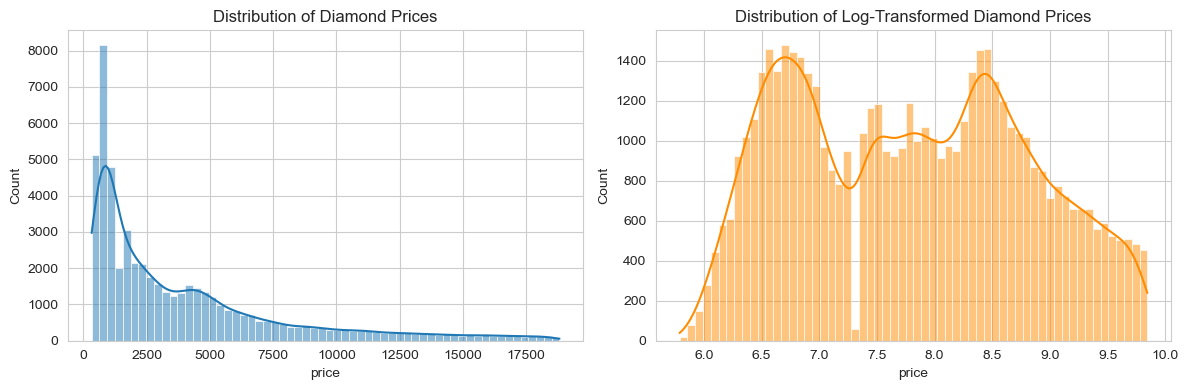

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean['price'], bins=60, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Diamond Prices')
sns.histplot(np.log1p(df_clean['price']), bins=60, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution of Log-Transformed Diamond Prices')
plt.tight_layout()
plt.show()

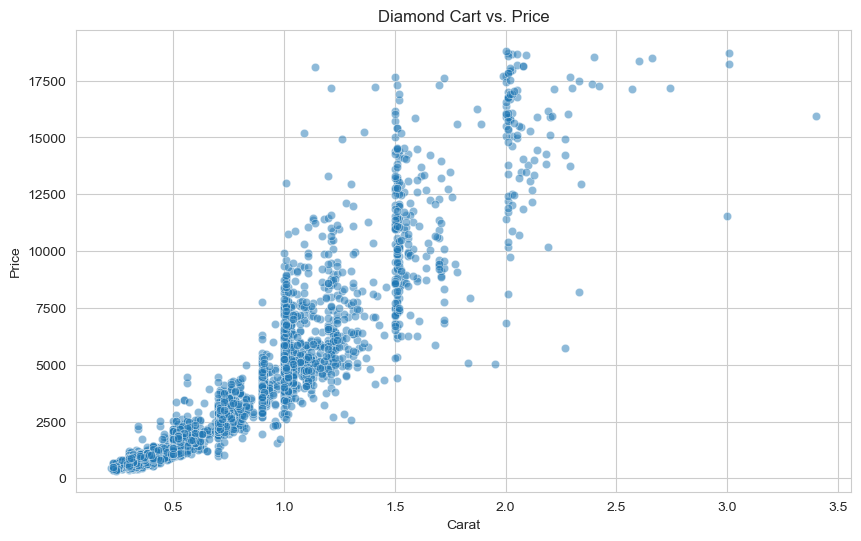

In [17]:
sns.scatterplot(data=df_clean.sample(3000, random_state=RANDOM_STATE), x='carat', y='price', alpha=0.5)
plt.title('Diamond Cart vs. Price')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.show()

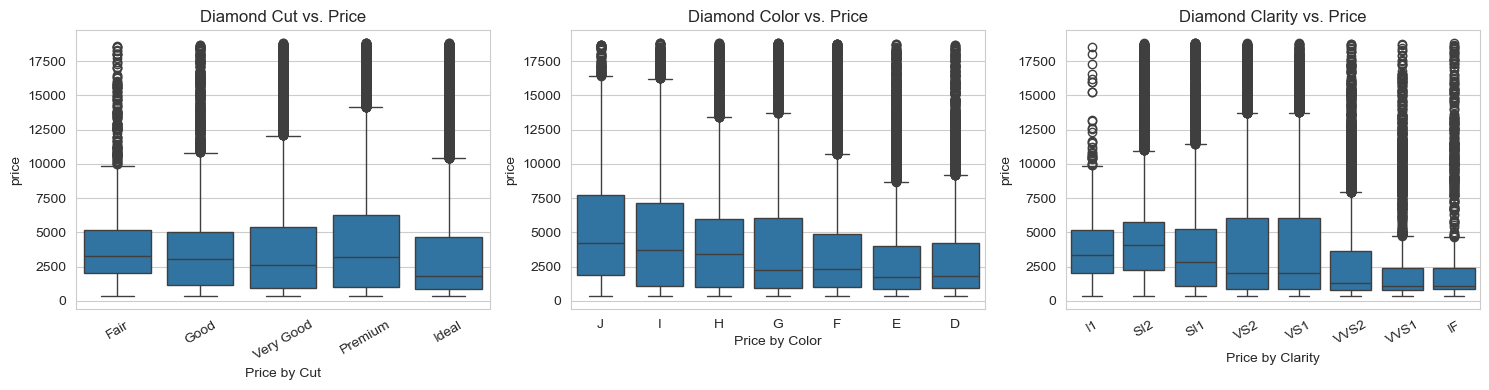

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
order_cut = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
order_color = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
order_clarity = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

sns.boxplot(data=df_clean, x='cut', y='price', order=order_cut, ax=axes[0])
axes[0].set_title('Diamond Cut vs. Price')
axes[0].set_xlabel('Price by Cut')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_clean, x='color', y='price', order=order_color, ax=axes[1])
axes[1].set_title('Diamond Color vs. Price')
axes[1].set_xlabel('Price by Color')

sns.boxplot(data=df_clean, x='clarity', y='price', order=order_clarity, ax=axes[2])
axes[2].set_title('Diamond Clarity vs. Price')
axes[2].set_xlabel('Price by Clarity')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show() # confounding variable effect

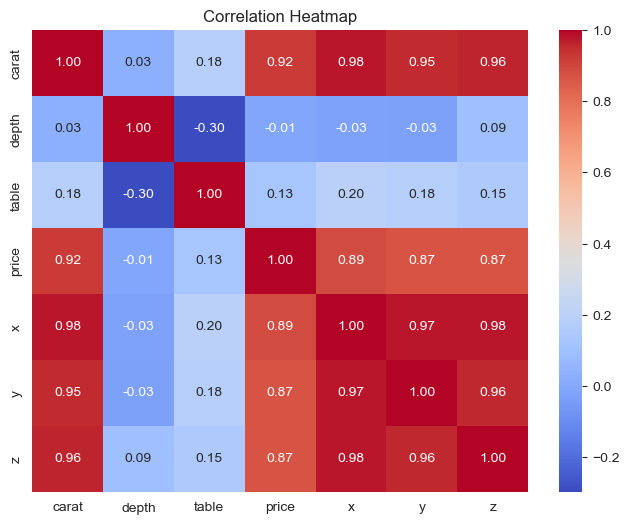

In [28]:
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show() # Multicollinearity


In [29]:
df_fe = df_clean.copy()
df_fe['volume'] = df_fe['x'] * df_fe['y'] * df_fe['z']
df_fe['density'] = df_fe['carat'] / df_fe['volume'].replace(0, np.nan)
df_fe['density'] = df_fe['density'].fillna(df_fe['density'].median())
df_fe['log_price'] = np.log1p(df_fe['price'])
df_fe[['carat', 'x', 'y', 'z', 'volume', 'density', 'price', 'log_price']].head()

,carat,x,y,z,volume,density,price,log_price
0,0.23,3.95,3.98,2.43,38.202030,0.006021,326,5.789960
1,0.21,3.89,3.84,2.31,34.505856,0.006086,326,5.789960
2,0.23,4.05,4.07,2.31,38.076885,0.006040,327,5.793014
3,0.29,4.20,4.23,2.63,46.724580,0.006207,334,5.814131
4,0.31,4.34,4.35,2.75,51.917250,0.005971,335,5.817111


In [30]:
df_fe[['volume', 'density', 'log_price','price']].corr()['price']

volume       0.904097
density      0.143005
log_price    0.895852
price        1.000000
Name: price, dtype: float64

In [31]:
df_fe


,carat,cut,color,clarity,depth,table,price,x,y,z,volume,density,log_price
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.202030,0.006021,5.789960
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.505856,0.006086,5.789960
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.076885,0.006040,5.793014
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.724580,0.006207,5.814131
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.917250,0.005971,5.817111
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50,115.920000,0.006211,7.922261
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61,118.110175,0.006096,7.922261
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56,114.449728,0.006116,7.922261
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74,140.766120,0.006109,7.922261


In [32]:
feature_cols = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'volume', 'density']
target_col = 'price'
log_target_col = 'log_price'

X = df_fe[feature_cols].copy()
y = df_fe[target_col].copy()
y_log = df_fe[log_target_col].copy()

In [33]:
X

,carat,cut,color,clarity,depth,table,volume,density
0,0.23,Ideal,E,SI2,61.5,55.0,38.202030,0.006021
1,0.21,Premium,E,SI1,59.8,61.0,34.505856,0.006086
2,0.23,Good,E,VS1,56.9,65.0,38.076885,0.006040
3,0.29,Premium,I,VS2,62.4,58.0,46.724580,0.006207
4,0.31,Good,J,SI2,63.3,58.0,51.917250,0.005971
...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,115.920000,0.006211
53936,0.72,Good,D,SI1,63.1,55.0,118.110175,0.006096
53937,0.70,Very Good,D,SI1,62.8,60.0,114.449728,0.006116
53938,0.86,Premium,H,SI2,61.0,58.0,140.766120,0.006109


In [34]:
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

ordinal_cols = ['cut', 'color', 'clarity']
numeric_cols_final = ['carat', 'depth', 'table', 'volume', 'density']

In [35]:
preprocessor = ColumnTransformer(transformers=[
        ('ord', Pipeline(steps=[
            ('encode',  OrdinalEncoder(categories=[cut_order, color_order, clarity_order])),
            ('scale', StandardScaler())
        ]), ordinal_cols),
        ('num', Pipeline(steps=[
            ('impute',SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), numeric_cols_final)
    ])

preprocessor

,transformers,"[('ord', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,"[['Fair', 'Good', ...], ['J', 'I', ...], ...]"
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'


In [36]:
X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(X, y, y_log, test_size=0.2, random_state=RANDOM_STATE)

In [37]:
print(f"Train set : {X_train.shape}")
print(f"Test set  : {X_test.shape}")

Train set : (43020, 8)
Test set  : (10755, 8)


In [38]:
def make_pipeline(model):
  return Pipeline(steps=[('preprocess', preprocessor), ('model', model)])

In [39]:
linear_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'ElasticNet Regression': ElasticNet()
}

In [40]:
trained_models = {}
target_used = {}

for name, model in linear_models.items():
  pipe = make_pipeline(model)
  pipe.fit(X_train, y_train_log)
  trained_models[name] = pipe
  target_used[name] = 'log_price'
  print(f"{name} trained.")

Linear Regression trained.
Ridge Regression trained.
Lasso Regression trained.
ElasticNet Regression trained.


In [41]:
knn_pipe = make_pipeline(KNeighborsRegressor())
knn_pipe.fit(X_train, y_train_log)
trained_models['KNN Regressor'] = knn_pipe
target_used['KNN Regressor'] = 'log_price'
print("KNN trained.")

KNN trained.


In [42]:
svr_sample_idx = X_train.sample(6000, random_state=RANDOM_STATE).index
svr_pipe = make_pipeline(SVR())
svr_pipe.fit(X_train.loc[svr_sample_idx], y_train_log.loc[svr_sample_idx])
trained_models['SVR'] = svr_pipe
target_used['SVR'] = 'log_price'
print("SVR trained.")

SVR trained.


In [43]:
tree_models = {
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest' : RandomForestRegressor(random_state=RANDOM_STATE)
}

for name, model in tree_models.items():
  pipe = make_pipeline(model)
  pipe.fit(X_train, y_train)
  trained_models[name] = pipe
  target_used[name] = 'price'
  print(f"{name} trained.")

Decision Tree trained.
Random Forest trained.


In [45]:
boosting_models = {
    'AdaBoost Regressor' : AdaBoostRegressor(random_state=RANDOM_STATE),
    'Gradient Boosting Regressor' : GradientBoostingRegressor(random_state=RANDOM_STATE),
    'XGBoost Regressor' : XGBRegressor(random_state=RANDOM_STATE)
}

for name, model in boosting_models.items():
  pipe = make_pipeline(model)
  pipe.fit(X_train, y_train)
  trained_models[name] = pipe
  target_used[name] = 'price'
  print(f"{name} trained.")

print(f"Total models trained: {len(trained_models)}")

AdaBoost Regressor trained.
Gradient Boosting Regressor trained.
XGBoost Regressor trained.
Total models trained: 11


In [46]:
def evaluate_model(name, pipe):
  if target_used[name] == 'log_price':
    preds_log = pipe.predict(X_test)
    preds = np.expm1(preds_log)
  else:
    preds = pipe.predict(X_test)

  preds = np.clip(preds, 0, None)
  mae = mean_absolute_error(y_test, preds)
  rmse = np.sqrt(mean_squared_error(y_test, preds))
  r2 = r2_score(y_test, preds)

  return preds, mae, rmse, r2

results = []
all_preds = {}

for name, pipe in trained_models.items():
  preds, mae, rmse, r2 = evaluate_model(name, pipe)
  all_preds[name] = preds
  results.append({'Model' : name, 'MAE ($)' : mae, 'RMSE ($)' : rmse, 'R2' : r2})

results_df = pd.DataFrame(results).sort_values('RMSE ($)').reset_index(drop=True)
results_df

,Model,MAE ($),RMSE ($),R2
0,Random Forest,275.614010,529.004424,0.982292
1,XGBoost Regressor,283.395966,536.322577,0.981799
2,Gradient Boosting Regressor,348.243915,624.888027,0.975291
3,Decision Tree,348.748644,698.455441,0.969130
4,SVR,361.064639,746.355927,0.964751
5,KNN Regressor,435.297189,766.870586,0.962787
6,AdaBoost Regressor,932.356714,1178.132934,0.912170
7,ElasticNet Regression,2103.142432,3350.117083,0.289811
8,Lasso Regression,2793.528411,4259.336624,-0.147990
9,Ridge Regression,2770.898359,113256.220136,-810.667563


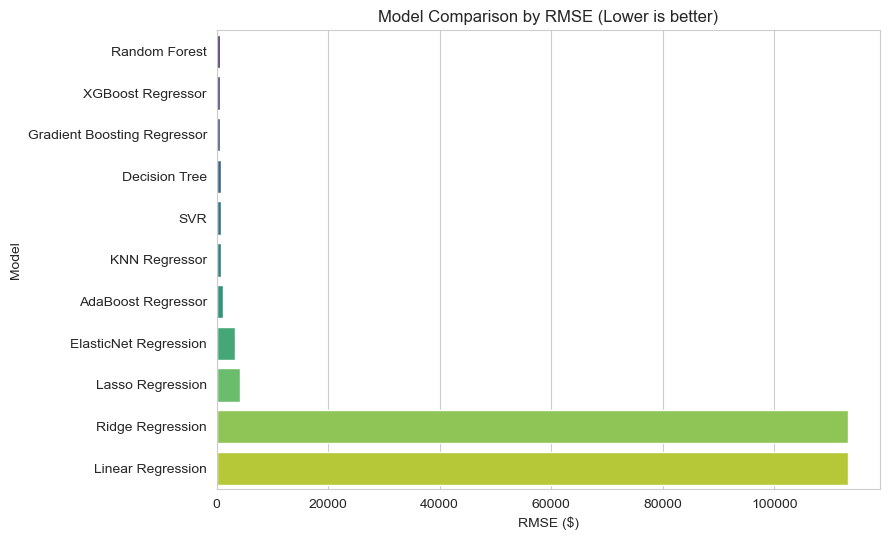

In [47]:
plt.figure(figsize=(9, 5.5))
order = results_df.sort_values('RMSE ($)')['Model']
sns.barplot(data=results_df, y='Model', x='RMSE ($)', order=order, palette='viridis')
plt.title('Model Comparison by RMSE (Lower is better)')
plt.tight_layout()
plt.show()

In [48]:
best_model_name = results_df.iloc[0]['Model']
print(f"Best model by test RMSE: {best_model_name}")

Best model by test RMSE: Random Forest


In [49]:
best_preds = all_preds[best_model_name]
residuals = y_test.values - best_preds

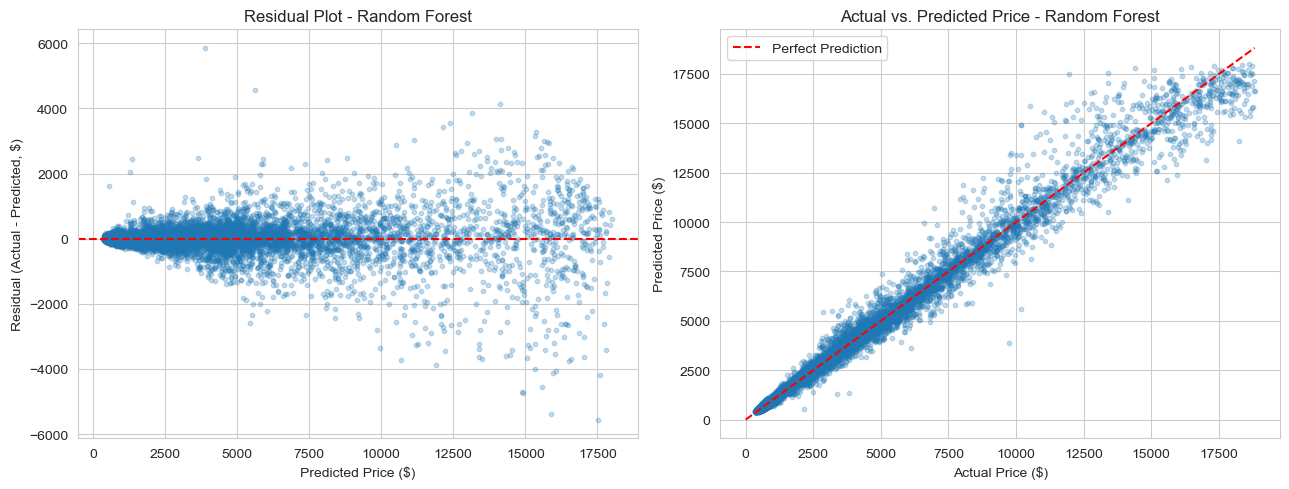

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].scatter(best_preds, residuals, alpha=0.25, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residual (Actual - Predicted, $)')
axes[0].set_title(f'Residual Plot - {best_model_name}')

axes[1].scatter(y_test, best_preds, alpha=0.25, s=10)
lims = [0, max(y_test.max(), best_preds.max())]
axes[1].plot(lims, lims, color='red', linestyle='--', label='Perfect Prediction')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title(f'Actual vs. Predicted Price - {best_model_name}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [51]:
error_df = X_test.copy()
error_df['actual_price'] = y_test.values
error_df['predicted_price'] = best_preds
error_df['abs_error'] = np.abs(error_df['actual_price'] - error_df['predicted_price'])
error_df['pct_error'] = error_df['abs_error'] / error_df['actual_price'] * 100

print('Top 10 worst absolute errors: ')
error_df.sort_values('abs_error', ascending=False).head(10)

Top 10 worst absolute errors: 


,carat,cut,color,clarity,depth,table,volume,density,actual_price,predicted_price,abs_error,pct_error
21654,1.41,Ideal,H,VS1,60.7,56.0,74.417262,0.018947,9752,3897.135000,5854.865000,60.037582
23868,2.02,Premium,F,SI2,61.0,59.0,331.996680,0.006084,11962,17517.052833,5555.052833,46.439164
22493,2.00,Good,D,SI2,63.8,57.0,314.941536,0.006350,10528,15900.810000,5372.810000,51.033530
22144,2.09,Premium,H,SI2,61.0,60.0,340.422264,0.006139,10182,14909.140000,4727.140000,46.426439
22147,2.01,Good,I,SI1,64.1,60.0,315.792576,0.006365,10184,14895.060000,4711.060000,46.259427
22142,1.01,Good,G,VS2,63.6,56.0,157.103856,0.006429,10181,5619.180000,4561.820000,44.807190
22982,1.71,Premium,G,VS2,61.3,58.0,271.158880,0.006306,11032,15573.034000,4541.034000,41.162382
24933,2.01,Premium,H,SI1,60.6,59.0,334.178327,0.006015,13387,17572.616667,4185.616667,31.266278
27525,2.01,Ideal,G,SI2,61.7,57.0,329.923530,0.006092,18259,14117.066667,4141.933333,22.684338
23783,2.45,Very Good,J,SI2,60.6,63.0,396.754436,0.006175,11843,15966.180000,4123.180000,34.815334


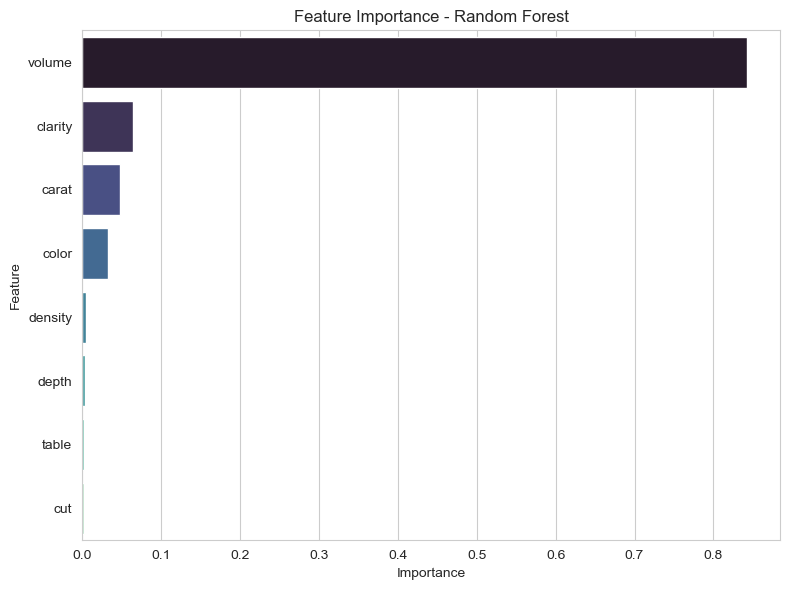

,feature,importance
6,volume,0.842252
2,clarity,0.064077
3,carat,0.048454
1,color,0.032431
7,density,0.004434
4,depth,0.004173
5,table,0.002269
0,cut,0.001910


In [52]:
best_pipe = trained_models[best_model_name]
feature_names = ordinal_cols + numeric_cols_final

if hasattr(best_pipe.named_steps['model'], 'feature_importances_'):
  importances = best_pipe.named_steps['model'].feature_importances_
  imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)

  plt.figure(figsize=(8, 6))
  sns.barplot(data=imp_df, y='feature', x='importance', palette='mako')
  plt.title(f'Feature Importance - {best_model_name}')
  plt.xlabel('Importance')
  plt.ylabel('Feature')
  plt.tight_layout()
  plt.show()
  display(imp_df)
else:
  print(f"No feature importance available for {best_model_name}.")

In [53]:
joblib.dump(best_pipe,'model.joblib')

['model.joblib']

In [54]:
metadata = {
    'model_name' : best_model_name,
    'target_scale' : target_used[best_model_name],
    'feature_columns' : feature_cols,
    'test_mae' : results_df.iloc[0]['MAE ($)'],
    'test_rmse' : results_df.iloc[0]['RMSE ($)'],
    'test_r2' : results_df.iloc[0]['R2']
}

In [55]:
joblib.dump(metadata, 'metadata.joblib')

['metadata.joblib']

In [56]:
def predict_new_diamnods(raw_df, pipe, meta):
  pipe = joblib.load('model.joblib')
  meta = joblib.load('metadata.joblib')

  data = raw_df.copy()
  data['volume'] = data['x'] * data['y'] * data['z']
  data['density'] = data['carat'] / data['volume'].replace(0, np.nan)
  data['density'] = data['density'].fillna(data['density'].median())

  X_new = data[meta['feature_columns']]
  raw_preds = pipe.predict(X_new)

  if meta['target_scale'] == 'log_price':
    preds = np.expm1(raw_preds)
  else:
    preds = raw_preds

  return np.clip(preds, 0, None)

In [57]:
new_diamonds = pd.DataFrame([
    {'carat': 0.3, 'cut': 'Ideal', 'color': 'E', 'clarity': 'SI1', 'depth': 61.5, 'table': 55.0, 'x': 3.95, 'y': 3.98, 'z': 2.43}
])

predicted_prices = predict_new_diamnods(new_diamonds, best_pipe, metadata)
print(f"Predicted prices: {round(predicted_prices[0],2)} $")

Predicted prices: 577.63 $
